In [1]:
print('Hello World.')

Hello World.


In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
def f(x):
    return 3*x**2 - 4*x + 5

In [8]:
f(3.0)

20.0

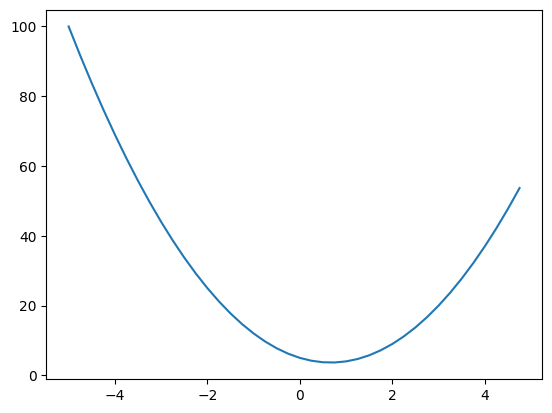

In [13]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)

plt.plot(xs, ys)

In [19]:
h = 0.001
x = 3.0

(f(x+h) - f(x))/ h

14.00300000000243

In [22]:
a = 2.0
b = -3.0
c= 10.0

d = a*b + c
print(d)

4.0


In [36]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
b += h
d2 = a * b + c

print('d1 =', d1)
print('d2 =', d2)

print('slope', (d2 - d1)/h)

d1 = 4.0
d2 = 4.0002
slope 2.0000000000042206


In [139]:
from graphviz import Digraph

def trace(root):
    """Builds a set of all all_edge and all_node in a graph."""

    all_node, all_edge = set(), set()
    def build(vertex):
        if vertex not in all_node:
            all_node.add(vertex)
            for child in vertex._previous:
                all_edge.add((child, vertex))
                build(child)
    build(root)
    return all_node, all_edge

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR indicates Left to Right -->

    all_node, all_edge = trace(root)
    for node in all_node:
        uid = str(id(node))
        # for any value in the graph, create a rectangular node for it. ('record')
        dot.node(name = uid, label = "{ %s | data %.4f | gradient %.4f }" % (node.label, node.data, node.gradient), shape='record')

        if node._operation:
            # if this value is the result of some operation, create an operation node for it.
            dot.node(name = uid + node._operation, label=node._operation)
            # and connect this node to it.
            dot.edge(uid + node._operation, uid)

    for node1, node2 in all_edge:
        # connect n1 to the op node of n2.
        dot.edge(str(id(node1)), str(id(node2)) + node2._operation)

    return dot

In [140]:
class Value:

    def __init__(self, data, _children=(), _operation = '', label = ''):
        self.data = data
        self.gradient = 0
        self._previous = set(_children)
        self._operation = _operation
        self.label = label

    def __repr__(self):
        return f"Value(data = {self.data})"

    def __add__(self, terms):
        add = Value(self.data + terms.data, (self, terms), '+')
        return add

    def __mul__(self, terms):
        multiply = Value(self.data * terms.data, (self, terms), '*')
        return multiply


In [141]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')

e = a*b
e.label = 'e'

d = e + c
d.label = 'd'

f = Value(-2.0, label='f')

L = d * f; L.label = 'L'
L

Value(data = -8.0)

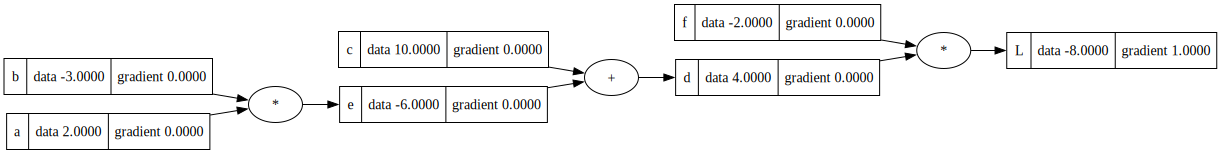

In [159]:
draw_dot(L)

In [160]:
# L = d * f

# f(x+h) - f(x)/h

#     ((d+h)*f - d*f)/h
# --> (d*f + h*f - d*f)/h
# --> (h*f) / h
# --> f

In [157]:
L.gradient = 1.0

In [169]:
def lol():

    h = 0.001
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data+=h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data


    print((L2-L1)/h)

lol()


-3.9999999999995595
